# Phân loại bệnh gan từ tập dữ liệu LPD — Notebook chạy được

**Mục tiêu:** Xây dựng một pipeline tiền xử lý dữ liệu và huấn luyện một mô hình **Random Forest** để phân loại _có bệnh gan_ / _không bệnh gan_.

**Nội dung notebook:**

1. Đọc và quan sát dữ liệu
2. Tiền xử lý (sửa giá trị bất hợp lý, tính/điền các chỉ số dựa trên quan hệ y sinh Albumin/TotalProtein/A_G, điền missing bằng median, winsorization)
3. Mã hóa biến phân loại, chia train/test
4. Huấn luyện Random Forest + cross-validation
5. Báo cáo kết quả: accuracy, precision, recall, f1, ROC-AUC, confusion matrix


In [1]:
import os
import warnings
warnings.filterwarnings('once')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

try:
    from imblearn.over_sampling import SMOTE
    imblearn_available = True
except Exception:
    imblearn_available = False

print('imblearn available:', imblearn_available)


imblearn available: True


In [2]:
DATA_PATH = './data/Liver_Patient_Dataset_(LPD)_train.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại {DATA_PATH}. Hãy kiểm tra đường dẫn và upload file vào đúng vị trí.")

df = pd.read_csv(DATA_PATH, encoding='latin1')

# Làm sạch tên cột
df.columns = df.columns.str.strip()               
df.columns = df.columns.str.replace('\xa0', ' ')  
df.columns = df.columns.str.replace(' ', '_')

print('Kích thước dữ liệu:', df.shape)
df.head()


Kích thước dữ liệu: (30691, 11)


,Age_of_the_patient,Gender_of_the_patient,Total_Bilirubin,Direct_Bilirubin,Alkphos_Alkaline_Phosphotase,Sgpt_Alamine_Aminotransferase,Sgot_Aspartate_Aminotransferase,Total_Protiens,ALB_Albumin,A/G_Ratio_Albumin_and_Globulin_Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [3]:
print(df.info())

print('\nSố missing theo cột:')
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('\nCác cột số:', numeric_cols)
print(df[numeric_cols].describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age_of_the_patient                    30689 non-null  float64
 1   Gender_of_the_patient                 29789 non-null  object 
 2   Total_Bilirubin                       30043 non-null  float64
 3   Direct_Bilirubin                      30130 non-null  float64
 4   Alkphos_Alkaline_Phosphotase          29895 non-null  float64
 5   Sgpt_Alamine_Aminotransferase         30153 non-null  float64
 6   Sgot_Aspartate_Aminotransferase       30229 non-null  float64
 7   Total_Protiens                        30228 non-null  float64
 8   ALB_Albumin                           30197 non-null  float64
 9   A/G_Ratio_Albumin_and_Globulin_Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [4]:
data = df.copy()
data.columns = [c.strip() for c in data.columns]

label_col = 'Result'
print('Cột nhãn sử dụng:', label_col)

# Đổi tên cột dài → tên ngắn gọn
col_map = {
    'Age_of_the_patient': 'Age',
    'Gender_of_the_patient': 'Sex',
    'Total_Bilirubin': 'Total_Bilirubin',
    'Direct_Bilirubin': 'Direct_Bilirubin',
    'Alkphos_Alkaline_Phosphotase': 'ALP',
    'Sgpt_Alamine_Aminotransferase': 'ALT',
    'Sgot_Aspartate_Aminotransferase': 'AST',
    'Total_Protiens': 'Total_Protein',
    'ALB_Albumin': 'Albumin',
    'A/G_Ratio_Albumin_and_Globulin_Ratio': 'A_G_Ratio'
}
data.rename(columns=col_map, inplace=True)

# Kiểm tra dữ liệu bilirubin
tb = data['Total_Bilirubin']
db = data['Direct_Bilirubin']
bad_direct = data.index[tb.notnull() & db.notnull() & (db > tb)].tolist()

if len(bad_direct) > 0:
    print(f'Có {len(bad_direct)} dòng Direct > Total — sẽ tự điều chỉnh.')
    data.loc[bad_direct, 'Direct_Bilirubin'] = data.loc[bad_direct, 'Total_Bilirubin']

# Thống kê giá trị thiếu
print('\nSố lượng giá trị thiếu theo cột:')
cols = [
    'Age',
    'Sex',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'ALP',
    'ALT',
    'AST',
    'Total_Protein',
    'Albumin',
    'A_G_Ratio'
]
print(data[cols].isnull().sum())


Cột nhãn sử dụng: Result
Có 134 dòng Direct > Total — sẽ tự điều chỉnh.

Số lượng giá trị thiếu theo cột:
Age                   2
Sex                 902
Total_Bilirubin     648
Direct_Bilirubin    561
ALP                 796
ALT                 538
AST                 462
Total_Protein       463
Albumin             494
A_G_Ratio           559
dtype: int64


In [5]:
def fill_ag_albumin_total(df):
    # Công thức: A_G_Ratio = Albumin / (Total_Protein - Albumin)
    mask_ag = df['A_G_Ratio'].isnull() & df['Albumin'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_ag, 'A_G_Ratio'] = df.loc[mask_ag, 'Albumin'] / (df.loc[mask_ag, 'Total_Protein'] - df.loc[mask_ag, 'Albumin'])

    mask_albumin = df['Albumin'].isnull() & df['A_G_Ratio'].notnull() & df['Total_Protein'].notnull()
    df.loc[mask_albumin, 'Albumin'] = (df.loc[mask_albumin, 'A_G_Ratio'] * df.loc[mask_albumin, 'Total_Protein']) / (1 + df.loc[mask_albumin, 'A_G_Ratio'])

    mask_total = df['Total_Protein'].isnull() & df['Albumin'].notnull() & df['A_G_Ratio'].notnull()
    df.loc[mask_total, 'Total_Protein'] = df.loc[mask_total, 'Albumin'] * (1 + 1.0/df.loc[mask_total, 'A_G_Ratio'])

    return df

data = fill_ag_albumin_total(data)

after_missing = data[['A_G_Ratio','Albumin','Total_Protein']].isnull().sum()
print('Missing sau khi điền bằng công thức:', after_missing)

# Sau khi dùng quan hệ, nếu vẫn missing thì điền bằng median (robust với outliers)
for c in ['Age','Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST','Total_Protein','Albumin','A_G_Ratio']:
    if c in data.columns:
        med = data[c].median()
        data[c] = data[c].fillna(med)

# Sex: điền bằng mode nếu missing
if 'Sex' in data.columns:
    mode_sex = data['Sex'].mode()
    if len(mode_sex)>0:
        data['Sex'].fillna(mode_sex[0], inplace=True)

print('\nMissing tổng sau điền median/mode:')
print(data.isnull().sum())


Missing sau khi điền bằng công thức: A_G_Ratio        158
Albumin          237
Total_Protein    136
dtype: int64

Missing tổng sau điền median/mode:
Age                 0
Sex                 0
Total_Bilirubin     0
Direct_Bilirubin    0
ALP                 0
ALT                 0
AST                 0
Total_Protein       0
Albumin             0
A_G_Ratio           0
Result              0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_36992\3363724937.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sex'].fillna(mode_sex[0], inplace=True)


In [6]:
# Winsorization: giới hạn các giá trị ngoại lai ở percentile 1% và 99%
cols_to_winsor = [c for c in ['Total_Bilirubin','Direct_Bilirubin','ALP','ALT','AST','Total_Protein','Albumin','A_G_Ratio'] if c in data.columns]

for c in cols_to_winsor:
    low = data[c].quantile(0.01)
    high = data[c].quantile(0.99)
    data[c] = data[c].clip(lower=low, upper=high)

print('Hoàn tất winsorization cho các cột:', cols_to_winsor)

# Kiểm tra phân phối (in mô tả sau xử lý)
print(data[cols_to_winsor].describe().T)


Hoàn tất winsorization cho các cột: ['Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio']
                    count        mean         std    min    25%     50%  \
Total_Bilirubin   30691.0    3.225626    5.465481   0.60    0.8    1.00   
Direct_Bilirubin  30691.0    1.458382    2.676445   0.10    0.2    0.30   
ALP               30691.0  285.105731  222.914502  97.00  176.0  209.00   
ALT               30691.0   74.973510  136.616941  12.00   23.0   35.00   
AST               30691.0   99.101593  165.239289  12.00   26.0   42.00   
Total_Protein     30691.0    6.479683    1.056223   3.60    5.8    6.60   
Albumin           30691.0    3.130230    0.777824   1.40    2.6    3.10   
A_G_Ratio         30691.0    0.941070    0.302553   0.37    0.7    0.92   

                    75%      max  
Total_Bilirubin     2.6    30.50  
Direct_Bilirubin    1.3    13.70  
ALP               293.0  1550.00  
ALT                61.0   950.00  
AST        

In [7]:
if 'Sex' in data.columns:
    data['Sex'] = data['Sex'].astype(str).str.strip().str.lower()
    data['Sex'] = data['Sex'].map({'male': 1, 'female': 0})

target = 'Result'
print('Sử dụng cột mục tiêu:', target)

feature_cols = [c for c in data.columns if c != target]
X = data[feature_cols].copy()
y = data[target].copy()

print('Số feature:', len(feature_cols))
print('Các feature đầu tiên:', feature_cols[:10])
print('Phân bố lớp (class distribution):')
print(y.value_counts(normalize=False))



Sử dụng cột mục tiêu: Result
Số feature: 10
Các feature đầu tiên: ['Age', 'Sex', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio']
Phân bố lớp (class distribution):
Result
1    21917
2     8774
Name: count, dtype: int64


In [8]:
# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

# Nếu muốn dùng SMOTE (nếu imblearn cài), chỉ áp dụng trên train
use_smote = False
if imblearn_available and use_smote:
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    print('After SMOTE, train shape:', X_train_sm.shape)
else:
    X_train_sm, y_train_sm = X_train, y_train

# Chuẩn hóa (standard) trước khi huấn luyện rừng (không bắt buộc nhưng hữu ích nếu bạn dùng các mô hình khác)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm.select_dtypes(include=[np.number]))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=[np.number]))

# Lưu danh sách feature numeric để mapping lại
numeric_features = X_train_sm.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric features used:', numeric_features)


Train: (24552, 10) Test: (6139, 10)
Numeric features used: ['Age', 'Sex', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT', 'AST', 'Total_Protein', 'Albumin', 'A_G_Ratio']


CV accuracy (5-fold): [0.99714926 0.998371   0.99837067 0.99796334 0.99816701]
CV accuracy mean: 0.9980042557938639

--- Kết quả trên tập test ---
Accuracy: 0.9985339631861867
Precision: 0.9984051036682615
Recall: 0.9995437956204379
F1-score: 0.9989741251567309
ROC-AUC: 0.9999909019069604

Classification report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      4384
           2       1.00      1.00      1.00      1755

    accuracy                           1.00      6139
   macro avg       1.00      1.00      1.00      6139
weighted avg       1.00      1.00      1.00      6139

Confusion matrix:
 [[4382    2]
 [   7 1748]]


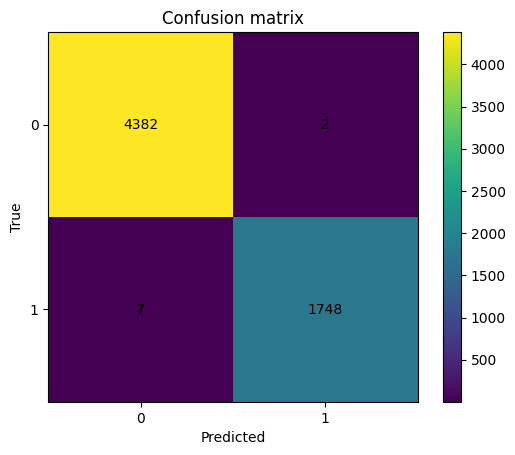

In [9]:
# Huấn luyện Random Forest trên dữ liệu đã chuẩn hóa
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Cross-validation (Stratified KFold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train_sm, cv=skf, scoring='accuracy')
print('CV accuracy (5-fold):', cv_scores)
print('CV accuracy mean:', cv_scores.mean())

# Fit trên toàn bộ train rồi đánh giá trên test
rf.fit(X_train_scaled, y_train_sm)

y_pred = rf.predict(X_test_scaled)

y_prob = None
try:
    y_prob = rf.predict_proba(X_test_scaled)[:,1]
except Exception:
    pass

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('\n--- Kết quả trên tập test ---')
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1-score:', f1)
print('ROC-AUC:', roc)

print('\nClassification report:\n')
print(classification_report(y_test, y_pred, zero_division=0))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

# Vẽ ma trận nhầm lẫn
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.show()


Top 10 feature theo importance:
ALP                 0.164838
ALT                 0.153865
AST                 0.151931
Total_Bilirubin     0.121855
Albumin             0.110912
Total_Protein       0.108888
A_G_Ratio           0.100475
Direct_Bilirubin    0.083959
Age                 0.002936
Sex                 0.000340
dtype: float64


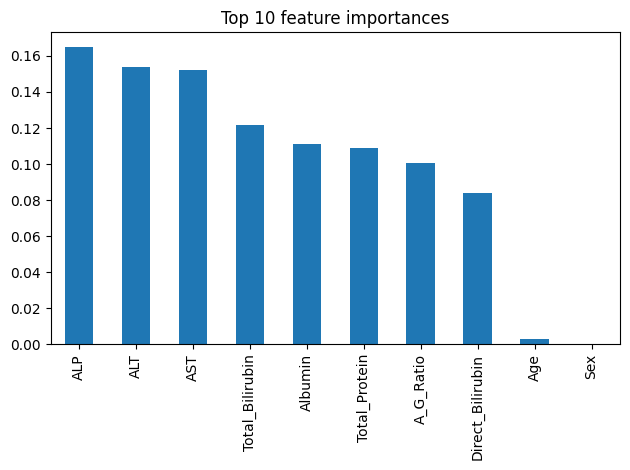

In [10]:
# Giá trị quan trọng của biến (feature importances)
importances = rf.feature_importances_
fi = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
print('Top 10 feature theo importance:')
print(fi.head(10))

# Vẽ biểu đồ nhỏ
plt.figure()
fi.head(10).plot(kind='bar')
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()


In [11]:
# Lưu mô hình và scaler để dùng sau này
import joblib
model_path = '/mnt/data/rf_liver_model.joblib'
scaler_path = '/mnt/data/scaler_liver.joblib'
joblib.dump(rf, "rf_liver_model.joblib")
joblib.dump(scaler, "scaler_liver.joblib")
print('Đã lưu model ->', model_path)
print('Đã lưu scaler ->', scaler_path)


Đã lưu model -> /mnt/data/rf_liver_model.joblib
Đã lưu scaler -> /mnt/data/scaler_liver.joblib


## Kết luận (tóm tắt)

- Notebook này thực hiện tiền xử lý theo hướng tận dụng tri thức y-sinh (tính/điền giá trị A/G, Albumin, Total Protein từ mối quan hệ thực tế) và kỹ thuật xử lý ngoại lệ (winsorization).
- Mô hình Random Forest được huấn luyện và đánh giá; kết quả (accuracy, precision, recall, F1, ROC-AUC) được in ở phần trên.
- Bạn có thể thay đổi tham số `use_smote = True` để thử cân bằng lớp bằng SMOTE nếu `imblearn` có sẵn.

Nếu bạn muốn mình điều chỉnh notebook (ví dụ: thêm GridSearchCV để tối ưu tham số, thêm báo cáo hình ảnh chi tiết, hoặc xuất file báo cáo PDF), hãy nói rõ yêu cầu — mình sẽ cập nhật ngay.
